# Situações Especiais e Movimentações — Base SIAPE

Este notebook mostra **quantos servidores estão fora da situação padrão de
exercício** — afastados para estudo, licenciados, cedidos a estados/municípios ou
em exercício fora do DF — e o motivo registrado. A grande maioria da base está em
situação normal (sem nenhuma dessas marcações); este notebook foca no grupo menor
que está em alguma situação especial.

Todos os números são agregados. Onde a população é muito pequena (poucas dezenas de
pessoas), mostramos apenas contagens por categoria — nunca o destino ou motivo de
uma pessoa específica.

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))
from src.viz_style import (
    agrupar_celulas_pequenas,
    aplicar_estilo_global,
    grafico_barra_horizontal,
    grafico_top_n_outros,
    resumo_informado,
)

DATA_PATH = Path("../data/raw/DB_SIAPE_processado_20260729.xlsx")
df = pd.read_excel(DATA_PATH, engine="openpyxl")

aplicar_estilo_global()
TOTAL = len(df)

## Situação atual por tipo de movimentação (visão geral)

**O que este gráfico mostra**: o campo mais abrangente da base sobre a situação de
cada servidor. A maior parte dos registros é "NI" (não informado / situação normal,
sem movimentação especial). Aqui mostramos apenas o grupo que **tem** alguma
movimentação especial registrada, agrupando os motivos menos comuns em "Outros".

In [2]:
COL_SITUACAO = "Tipo de movimentação_Situação atual por tipo de movimentação"

_, pct_informado_situacao = resumo_informado(df[COL_SITUACAO], TOTAL)
print(f"{pct_informado_situacao}% dos servidores têm alguma movimentação especial registrada.")
print(f"Os demais {round(100 - pct_informado_situacao, 1)}% estão em situação normal (\"NI\").")

23.3% dos servidores têm alguma movimentação especial registrada.
Os demais 76.7% estão em situação normal ("NI").


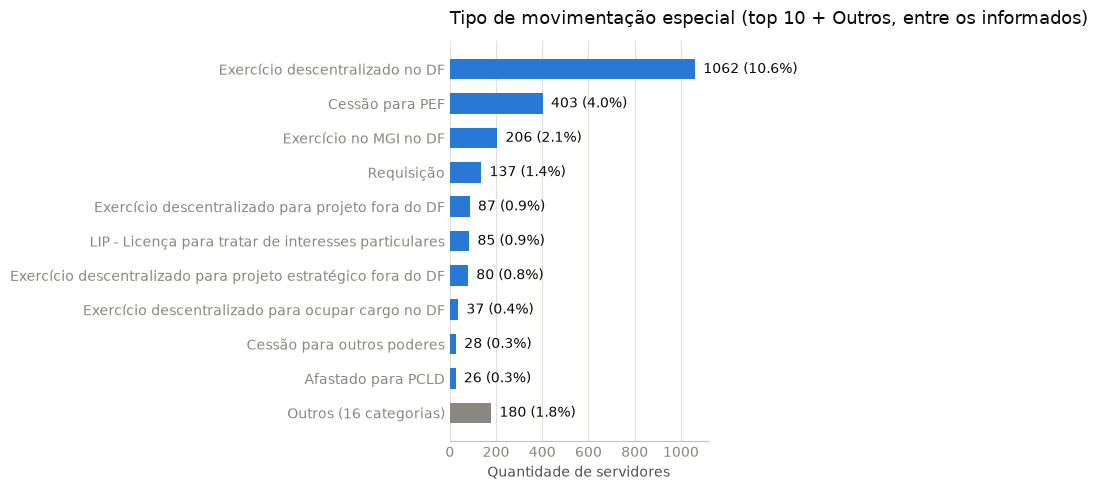

In [3]:
situacao_informada = df.loc[df[COL_SITUACAO] != "NI", COL_SITUACAO]
contagem_situacao = grafico_top_n_outros(
    situacao_informada, TOTAL,
    "Tipo de movimentação especial (top 10 + Outros, entre os informados)",
)

## Afastados para estudo

**O que mostra**: servidores formalmente afastados para cursar pós-graduação. Como
essa população é pequena (poucas dezenas de pessoas), tipos com menos de 5
servidores são agrupados em "Outras" para não identificar indivíduos.

In [4]:
contagem_afastamento, pct_afastamento = resumo_informado(
    df["Tipo de afastamento_Afastados para estudo"], TOTAL
)
contagem_escolaridade_afastamento, _ = resumo_informado(
    df["Escolaridade do afastamento_Afastados para estudo"], TOTAL
)

contagem_afastamento_protegida, _ = agrupar_celulas_pequenas(contagem_afastamento, minimo=5)
contagem_escolaridade_afastamento_protegida, _ = agrupar_celulas_pequenas(
    contagem_escolaridade_afastamento, minimo=5
)

print(f"{int(contagem_afastamento.sum())} servidores ({pct_afastamento}% da base) estão afastados para estudo.")
print()
print("Por tipo de afastamento:")
display(contagem_afastamento_protegida.to_frame("quantidade"))
print("Por nível de escolaridade do afastamento:")
display(contagem_escolaridade_afastamento_protegida.to_frame("quantidade"))

29 servidores (0.3% da base) estão afastados para estudo.

Por tipo de afastamento:


,quantidade
Afastado para PCLD,26
"Outras (poucos casos, 1 categorias agrupadas)",3


Por nível de escolaridade do afastamento:


,quantidade
Doutorado,21
Mestrado,6
"Outras (poucos casos, 1 categorias agrupadas)",2


## Licenciados

**O que mostra**: servidores em licença (interesses particulares, organismo
internacional ou para acompanhar cônjuge).

In [5]:
contagem_licenca, pct_licenca = resumo_informado(df["Tipo de licença_Licenciados"], TOTAL)
print(f"{int(contagem_licenca.sum())} servidores ({pct_licenca}% da base) estão licenciados.")
contagem_licenca.to_frame("quantidade")

105 servidores (1.1% da base) estão licenciados.


,quantidade
Tipo de licença_Licenciados,
LIP - Licença para tratar de interesses particulares,85
Licença para atuar em organismo internacional,15
LAC - Licença para acompanhar cônjuge,5


## Cedidos para estados e municípios

**O que mostra**: quantos servidores estão cedidos a governos estaduais ou
municipais. A população é muito pequena (a maioria dos destinos tem 1 ou 2
servidores), então **não detalhamos o destino individual** — isso poderia, na
prática, identificar pessoas específicas.

In [6]:
contagem_cedidos, pct_cedidos = resumo_informado(
    df["Órgão/Entidade_Cedidos para estados e Municípios"], TOTAL
)
n_destinos = len(contagem_cedidos)
print(
    f"{int(contagem_cedidos.sum())} servidores ({pct_cedidos}% da base) estão cedidos "
    f"a estados/municípios, espalhados por {n_destinos} destinos diferentes "
    f"(a maioria com 1 ou 2 servidores cada)."
)

17 servidores (0.2% da base) estão cedidos a estados/municípios, espalhados por 14 destinos diferentes (a maioria com 1 ou 2 servidores cada).


## Servidores em exercício fora do DF

**O que mostra**: servidores que, embora vinculados ao órgão em Brasília, exercem
suas funções em outro estado.

In [7]:
contagem_fora_df, pct_fora_df = resumo_informado(df["UF_Servidores em órgãos fora do DF"], TOTAL)
print(f"{int(contagem_fora_df.sum())} servidores ({pct_fora_df}% da base) exercem suas funções fora do DF.")

354 servidores (3.5% da base) exercem suas funções fora do DF.


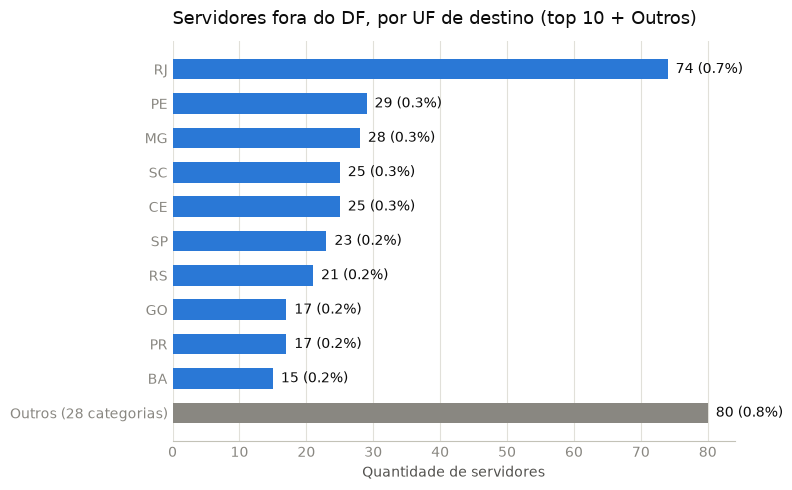

In [8]:
fora_df_uf = df.loc[df["UF_Servidores em órgãos fora do DF"] != "NI", "UF_Servidores em órgãos fora do DF"]
_ = grafico_top_n_outros(fora_df_uf, TOTAL, "Servidores fora do DF, por UF de destino (top 10 + Outros)")

## Resumo consolidado

In [9]:
from IPython.display import Markdown, display

resumo_md = f"""
- **{pct_informado_situacao}%** dos servidores têm alguma movimentação especial registrada; os demais **{round(100 - pct_informado_situacao, 1)}%** estão em situação normal.
- **{int(contagem_afastamento.sum())}** servidores estão afastados para estudo (a maioria para doutorado).
- **{int(contagem_licenca.sum())}** servidores estão licenciados.
- **{int(contagem_cedidos.sum())}** servidores estão cedidos a estados/municípios.
- **{int(contagem_fora_df.sum())}** servidores exercem suas funções fora do DF, com destaque para o Rio de Janeiro.

No conjunto, situações especiais (afastamento, licença, cessão ou exercício fora do DF) são exceção, não regra — a grande maioria do quadro está em exercício normal no DF. Nenhum servidor específico foi identificado nesta análise.
"""

display(Markdown(resumo_md))


- **23.3%** dos servidores têm alguma movimentação especial registrada; os demais **76.7%** estão em situação normal.
- **29** servidores estão afastados para estudo (a maioria para doutorado).
- **105** servidores estão licenciados.
- **17** servidores estão cedidos a estados/municípios.
- **354** servidores exercem suas funções fora do DF, com destaque para o Rio de Janeiro.

No conjunto, situações especiais (afastamento, licença, cessão ou exercício fora do DF) são exceção, não regra — a grande maioria do quadro está em exercício normal no DF. Nenhum servidor específico foi identificado nesta análise.
